# 🎯 NOTEBOOK 05: SISTEMA DE SCOUTING

**Objetivo:** Identificar jogadores com melhor custo-benefício  
**Input:** Gold layer (features prontas)  
**Output:** Rankings e recomendações por posição

In [1]:
# Setup
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from utils.config import (
    GOLD_FEATURES, GOLD_SCOUTING,
    CARTOLA_POSITIONS
)
from utils.logger import setup_logger

logger = setup_logger('scouting', 'logs/scouting.log')

# Configurar visualizações
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)

print("✅ Setup completo!")

✅ Setup completo!


---
## 📥 1. CARREGAR FEATURES

In [2]:
print("="*70)
print(" "*20 + "📥 CARREGANDO FEATURES")
print("="*70 + "\n")

# Tentar Gold primeiro, depois Silver
features_file = GOLD_FEATURES / 'cartola_features.parquet'

if not features_file.exists():
    print("⚠️  Gold layer não encontrada, tentando Silver...\n")
    from utils.config import SILVER_CARTOLA
    features_file = SILVER_CARTOLA / 'atletas_clean.parquet'

if features_file.exists():
    df = pd.read_parquet(features_file)
    
    print(f"✅ Features carregadas: {len(df):,} atletas")
    print(f"   Colunas: {len(df.columns)}")
    print(f"   Arquivo: {features_file.name}")
    
    # Verificar colunas essenciais para scouting
    colunas_essenciais = ['atleta_id', 'apelido', 'posicao_nome', 'preco_num']
    
    # Coluna de pontos (pode ter nomes diferentes)
    coluna_pontos = None
    for col in ['pontos_num', 'pontuacao', 'media_num']:
        if col in df.columns:
            coluna_pontos = col
            break
    
    if coluna_pontos:
        colunas_essenciais.append(coluna_pontos)
        
        # Padronizar para pontos_num
        if coluna_pontos != 'pontos_num':
            df['pontos_num'] = df[coluna_pontos]
            print(f"\n✅ Padronizado: '{coluna_pontos}' → 'pontos_num'")
    
    print(f"\n📋 Verificação:")
    for col in colunas_essenciais:
        existe = col in df.columns
        print(f"   {'✅' if existe else '❌'} {col}")
    
    logger.info(f"Features carregadas: {len(df)} atletas")

else:
    print("❌ Arquivo não encontrado!")
    df = pd.DataFrame()

print("\n" + "="*70)

                    📥 CARREGANDO FEATURES

✅ Features carregadas: 692 atletas
   Colunas: 32
   Arquivo: cartola_features.parquet

📋 Verificação:
   ✅ atleta_id
   ✅ apelido
   ✅ posicao_nome
   ✅ preco_num
   ✅ pontos_num
2026-02-12 13:21:00 | scouting | INFO | Features carregadas: 692 atletas



---
## 🔢 2. CALCULAR VALUE SCORE

In [3]:
if not df.empty and 'pontos_num' in df.columns and 'preco_num' in df.columns:
    
    print("="*70)
    print(" "*20 + "🔢 CALCULANDO VALUE SCORE")
    print("="*70 + "\n")
    
    # Filtrar apenas atletas com preço > 0
    df_scouting = df[df['preco_num'] > 0].copy()
    
    print(f"📊 Atletas com preço válido: {len(df_scouting):,}\n")
    
    # 1. VALUE SCORE SIMPLES (pontos / preço)
    df_scouting['value_score'] = df_scouting['pontos_num'] / df_scouting['preco_num']
    
    print("✅ Value Score calculado")
    print(f"   Fórmula: pontos_num / preco_num")
    print(f"   Média: {df_scouting['value_score'].mean():.4f}")
    print(f"   Máximo: {df_scouting['value_score'].max():.4f}\n")
    
    # 2. VALUE SCORE NORMALIZADO (0-100)
    from sklearn.preprocessing import MinMaxScaler
    
    scaler = MinMaxScaler(feature_range=(0, 100))
    df_scouting['value_score_normalized'] = scaler.fit_transform(
        df_scouting[['value_score']]
    )
    
    print("✅ Value Score Normalizado (0-100)")
    print(f"   Média: {df_scouting['value_score_normalized'].mean():.2f}")
    print(f"   Máximo: {df_scouting['value_score_normalized'].max():.2f}\n")
    
    # 3. CLASSIFICAÇÃO
    df_scouting['value_categoria'] = pd.cut(
        df_scouting['value_score_normalized'],
        bins=[0, 25, 50, 75, 100],
        labels=['Baixo', 'Médio', 'Alto', 'Excelente']
    )
    
    print("✅ Categorias de Value Score:")
    print(df_scouting['value_categoria'].value_counts().sort_index())
    
    logger.info(f"Value Score calculado para {len(df_scouting)} atletas")
    
    print("\n" + "="*70)

else:
    print("❌ Não foi possível calcular Value Score!")
    df_scouting = pd.DataFrame()

                    🔢 CALCULANDO VALUE SCORE

📊 Atletas com preço válido: 692

✅ Value Score calculado
   Fórmula: pontos_num / preco_num
   Média: 0.2315
   Máximo: 2.0792

✅ Value Score Normalizado (0-100)
   Média: 39.74
   Máximo: 100.00

✅ Categorias de Value Score:
value_categoria
Baixo         13
Médio        541
Alto         122
Excelente     15
Name: count, dtype: int64
2026-02-12 13:21:01 | scouting | INFO | Value Score calculado para 692 atletas



---
## 🏆 3. TOP 20 GERAL (MELHOR CUSTO-BENEFÍCIO)

In [4]:
if not df_scouting.empty:
    
    print("="*70)
    print(" "*15 + "🏆 TOP 20 MELHOR CUSTO-BENEFÍCIO GERAL")
    print("="*70 + "\n")
    
    # Selecionar colunas para display
    display_cols = ['apelido', 'posicao_nome', 'pontos_num', 'preco_num', 'value_score', 'value_score_normalized']
    available_cols = [col for col in display_cols if col in df_scouting.columns]
    
    top20_geral = df_scouting.nlargest(20, 'value_score')[available_cols].copy()
    
    # Formatar
    top20_geral['value_score'] = top20_geral['value_score'].round(4)
    top20_geral['value_score_normalized'] = top20_geral['value_score_normalized'].round(1)
    top20_geral['pontos_num'] = top20_geral['pontos_num'].round(2)
    top20_geral['preco_num'] = top20_geral['preco_num'].round(2)
    
    print(top20_geral.to_string(index=False))
    
    print("\n" + "="*70)

else:
    print("❌ Sem dados para ranking!")

               🏆 TOP 20 MELHOR CUSTO-BENEFÍCIO GERAL

           apelido posicao_nome  pontos_num  preco_num  value_score  value_score_normalized
        Marcelinho          MEI        6.30       3.03       2.0792                   100.0
         Léo Derik          LAT       10.00       5.14       1.9455                    95.6
     Higor Meritão          MEI       13.40       7.97       1.6813                    87.0
       Jean Carlos          MEI       13.00       7.83       1.6603                    86.3
   Gustavo Marques          ZAG        9.70       5.86       1.6553                    86.2
      Mateus Silva          LAT        9.70       5.86       1.6553                    86.2
    Gabriel Menino          MEI       16.70      10.77       1.5506                    82.8
       Arthur Dias          ZAG        8.00       5.26       1.5209                    81.8
  Gilmar Dal Pozzo          TEC        7.95       5.24       1.5172                    81.7
       Walter Clar        

---
## ⚽ 4. TOP 10 POR POSIÇÃO

In [5]:
if not df_scouting.empty and 'posicao_nome' in df_scouting.columns:
    
    print("="*70)
    print(" "*15 + "⚽ TOP 10 POR POSIÇÃO")
    print("="*70 + "\n")
    
    posicoes = df_scouting['posicao_nome'].unique()
    
    for posicao in sorted(posicoes):
        
        if posicao in ['TEC']:  # Pular técnicos
            continue
        
        print(f"\n{'='*70}")
        print(f" "*25 + f"🎯 {posicao}")
        print(f"{'='*70}\n")
        
        df_pos = df_scouting[df_scouting['posicao_nome'] == posicao]
        
        if len(df_pos) == 0:
            print("   Sem atletas nesta posição")
            continue
        
        top10_pos = df_pos.nlargest(10, 'value_score')[[
            'apelido', 'pontos_num', 'preco_num', 'value_score', 'value_score_normalized'
        ]].copy()
        
        # Formatar
        top10_pos['value_score'] = top10_pos['value_score'].round(4)
        top10_pos['value_score_normalized'] = top10_pos['value_score_normalized'].round(1)
        top10_pos['pontos_num'] = top10_pos['pontos_num'].round(2)
        top10_pos['preco_num'] = top10_pos['preco_num'].round(2)
        
        print(top10_pos.to_string(index=False))
        
        print(f"\n📊 Estatísticas {posicao}:")
        print(f"   Total de atletas: {len(df_pos)}")
        print(f"   Preço médio: C$ {df_pos['preco_num'].mean():.2f}")
        print(f"   Pontos médios: {df_pos['pontos_num'].mean():.2f}")
        print(f"   Value Score médio: {df_pos['value_score'].mean():.4f}")
    
    print("\n" + "="*70)

else:
    print("❌ Sem dados de posição!")

               ⚽ TOP 10 POR POSIÇÃO


                         🎯 ATA

         apelido  pontos_num  preco_num  value_score  value_score_normalized
 Matheus Martins        10.0       7.60       1.3158                    75.1
           Erick        12.5      10.11       1.2364                    72.5
   Renato Kayzer        10.4       8.56       1.2150                    71.8
Andrey Fernandes         1.7       1.41       1.2057                    71.5
           Plata        10.6       9.44       1.1229                    68.8
         Viveros        10.2       9.30       1.0968                    68.0
           Ítalo         2.9       2.65       1.0943                    67.9
         Alesson         9.7       9.13       1.0624                    66.8
         Mendoza         8.2       7.78       1.0540                    66.6
           Fabri         5.4       5.17       1.0445                    66.3

📊 Estatísticas ATA:
   Total de atletas: 171
   Preço médio: C$ 5.83
   Pontos méd

---
## 📊 5. VISUALIZAÇÕES

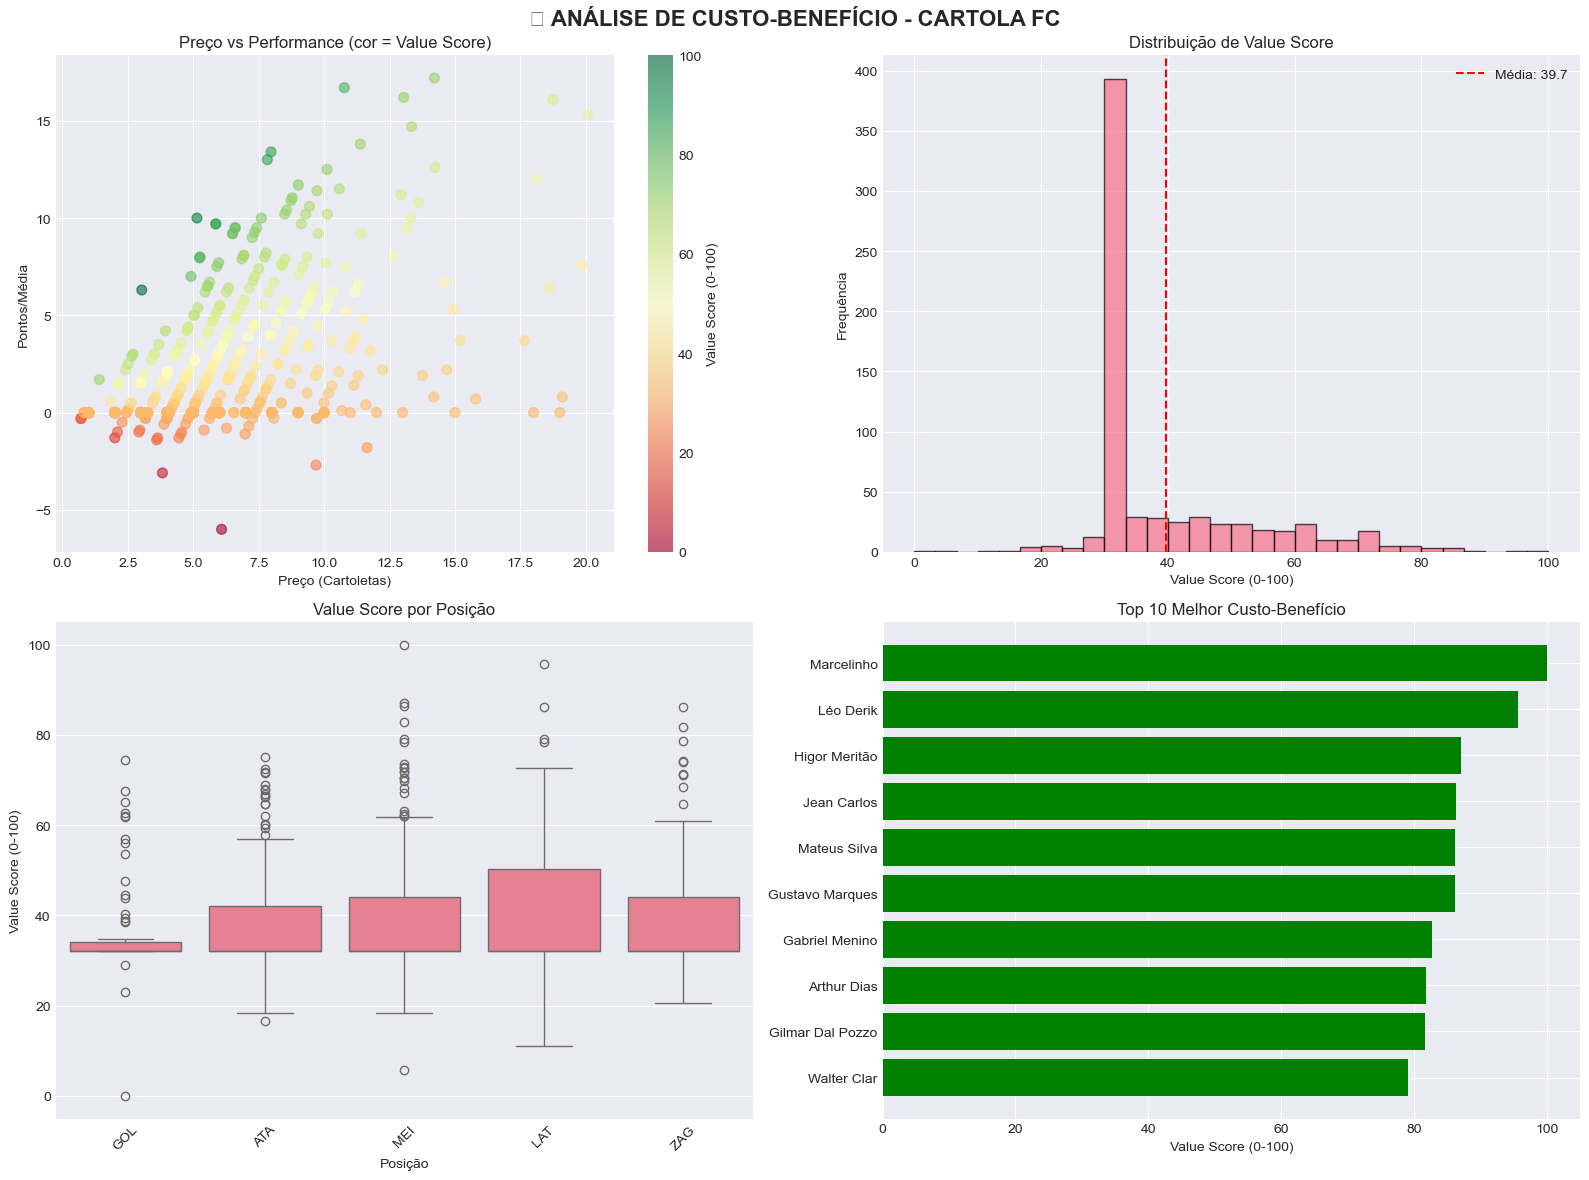


✅ Visualizações geradas!


In [6]:
if not df_scouting.empty:
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('📊 ANÁLISE DE CUSTO-BENEFÍCIO - CARTOLA FC', fontsize=16, fontweight='bold')
    
    # 1. Scatter: Preço vs Pontos (com value score em cores)
    scatter = axes[0,0].scatter(
        df_scouting['preco_num'], 
        df_scouting['pontos_num'],
        c=df_scouting['value_score_normalized'],
        cmap='RdYlGn',
        alpha=0.6,
        s=50
    )
    axes[0,0].set_xlabel('Preço (Cartoletas)')
    axes[0,0].set_ylabel('Pontos/Média')
    axes[0,0].set_title('Preço vs Performance (cor = Value Score)')
    plt.colorbar(scatter, ax=axes[0,0], label='Value Score (0-100)')
    
    # 2. Distribuição de Value Score
    axes[0,1].hist(df_scouting['value_score_normalized'], bins=30, edgecolor='black', alpha=0.7)
    axes[0,1].axvline(df_scouting['value_score_normalized'].mean(), 
                     color='red', linestyle='--', 
                     label=f'Média: {df_scouting["value_score_normalized"].mean():.1f}')
    axes[0,1].set_xlabel('Value Score (0-100)')
    axes[0,1].set_ylabel('Frequência')
    axes[0,1].set_title('Distribuição de Value Score')
    axes[0,1].legend()
    
    # 3. Boxplot por posição
    if 'posicao_nome' in df_scouting.columns:
        df_plot = df_scouting[df_scouting['posicao_nome'] != 'TEC']
        sns.boxplot(data=df_plot, x='posicao_nome', y='value_score_normalized', ax=axes[1,0])
        axes[1,0].set_xlabel('Posição')
        axes[1,0].set_ylabel('Value Score (0-100)')
        axes[1,0].set_title('Value Score por Posição')
        axes[1,0].tick_params(axis='x', rotation=45)
    
    # 4. Top 10 (barras horizontais)
    top10_viz = df_scouting.nlargest(10, 'value_score_normalized')[[
        'apelido', 'value_score_normalized'
    ]].sort_values('value_score_normalized')
    
    axes[1,1].barh(top10_viz['apelido'], top10_viz['value_score_normalized'], color='green')
    axes[1,1].set_xlabel('Value Score (0-100)')
    axes[1,1].set_title('Top 10 Melhor Custo-Benefício')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Visualizações geradas!")

else:
    print("❌ Sem dados para visualizar!")

---
## 💎 6. IDENTIFICAR PECHINCHAS

In [7]:
if not df_scouting.empty:
    
    print("="*70)
    print(" "*20 + "💎 IDENTIFICANDO PECHINCHAS")
    print("="*70 + "\n")
    
    # Critério: Value Score > 75 E Preço < Mediana
    preco_mediano = df_scouting['preco_num'].median()
    
    pechinchas = df_scouting[
        (df_scouting['value_score_normalized'] > 75) &
        (df_scouting['preco_num'] < preco_mediano)
    ].copy()
    
    print(f"📊 Critérios:")
    print(f"   Value Score > 75")
    print(f"   Preço < C$ {preco_mediano:.2f} (mediana)\n")
    
    if len(pechinchas) > 0:
        print(f"✅ {len(pechinchas)} PECHINCHAS ENCONTRADAS!\n")
        
        pechinchas_display = pechinchas.sort_values('value_score_normalized', ascending=False)[[
            'apelido', 'posicao_nome', 'pontos_num', 'preco_num', 
            'value_score', 'value_score_normalized'
        ]].head(15)
        
        # Formatar
        pechinchas_display['value_score'] = pechinchas_display['value_score'].round(4)
        pechinchas_display['value_score_normalized'] = pechinchas_display['value_score_normalized'].round(1)
        pechinchas_display['pontos_num'] = pechinchas_display['pontos_num'].round(2)
        pechinchas_display['preco_num'] = pechinchas_display['preco_num'].round(2)
        
        print(pechinchas_display.to_string(index=False))
    
    else:
        print("⚠️  Nenhuma pechincha encontrada com esses critérios")
        print("   Tente ajustar os limites...")
    
    print("\n" + "="*70)

else:
    print("❌ Sem dados!")

                    💎 IDENTIFICANDO PECHINCHAS

📊 Critérios:
   Value Score > 75
   Preço < C$ 5.00 (mediana)

✅ 2 PECHINCHAS ENCONTRADAS!

   apelido posicao_nome  pontos_num  preco_num  value_score  value_score_normalized
Marcelinho          MEI         6.3       3.03       2.0792                   100.0
João Paulo          ZAG         7.0       4.91       1.4257                    78.7



---
## 💾 7. SALVAR RANKINGS (GOLD LAYER)

In [8]:
if not df_scouting.empty:
    
    print("="*70)
    print(" "*20 + "💾 SALVANDO RANKINGS")
    print("="*70 + "\n")
    
    # Criar diretório
    GOLD_SCOUTING.mkdir(parents=True, exist_ok=True)
    
    # 1. Ranking completo
    output_completo = GOLD_SCOUTING / 'ranking_completo.parquet'
    df_scouting_sorted = df_scouting.sort_values('value_score', ascending=False)
    df_scouting_sorted.to_parquet(output_completo, compression='snappy', index=False)
    
    print(f"✅ Ranking completo: ranking_completo.parquet")
    print(f"   {len(df_scouting_sorted):,} atletas\n")
    
    # 2. Top 100
    output_top100 = GOLD_SCOUTING / 'top_100_value.csv'
    df_scouting_sorted.head(100).to_csv(output_top100, index=False, encoding='utf-8')
    
    print(f"✅ Top 100: top_100_value.csv\n")
    
    # 3. Pechinchas
    if len(pechinchas) > 0:
        output_pechinchas = GOLD_SCOUTING / 'pechinchas.csv'
        pechinchas.sort_values('value_score_normalized', ascending=False).to_csv(
            output_pechinchas, index=False, encoding='utf-8'
        )
        print(f"✅ Pechinchas: pechinchas.csv ({len(pechinchas)} jogadores)\n")
    
    # 4. Rankings por posição
    if 'posicao_nome' in df_scouting.columns:
        for posicao in df_scouting['posicao_nome'].unique():
            if posicao == 'TEC':
                continue
            
            df_pos = df_scouting[df_scouting['posicao_nome'] == posicao]
            df_pos_sorted = df_pos.sort_values('value_score', ascending=False)
            
            output_pos = GOLD_SCOUTING / f'ranking_{posicao.lower()}.csv'
            df_pos_sorted.to_csv(output_pos, index=False, encoding='utf-8')
            
            print(f"✅ Ranking {posicao}: ranking_{posicao.lower()}.csv ({len(df_pos)} atletas)")
    
    print(f"\n📁 Arquivos salvos em: {GOLD_SCOUTING}")
    
    logger.info(f"Rankings salvos: {len(df_scouting)} atletas")
    
    print("\n" + "="*70)

else:
    print("❌ Sem dados para salvar!")

                    💾 SALVANDO RANKINGS

✅ Ranking completo: ranking_completo.parquet
   692 atletas

✅ Top 100: top_100_value.csv

✅ Pechinchas: pechinchas.csv (2 jogadores)

✅ Ranking GOL: ranking_gol.csv (66 atletas)
✅ Ranking ATA: ranking_ata.csv (171 atletas)
✅ Ranking MEI: ranking_mei.csv (217 atletas)
✅ Ranking LAT: ranking_lat.csv (105 atletas)
✅ Ranking ZAG: ranking_zag.csv (113 atletas)

📁 Arquivos salvos em: D:\football analytics project\data\gold\scouting
2026-02-12 13:21:01 | scouting | INFO | Rankings salvos: 692 atletas



---
## 📋 8. RESUMO FINAL

---
## 🏟️ 9. PREPARAR DIMENSÃO DE CLUBES (POWER BI)

**Correção:** Extrair TODOS os clubes do ranking (não apenas os 15 da Série A)

In [9]:
print("="*70)
print(" "*20 + "🏟️ CRIANDO DIM_CLUBES")
print("="*70 + "\n")

# Extrair código do clube da URL da foto
import re

def extrair_codigo_clube(url_foto):
    """Extrai código do clube da URL da foto"""
    if pd.isna(url_foto):
        return None
    match = re.search(r'/silhuetas/([A-Z]+)/', url_foto)
    if match:
        return match.group(1)
    return None

df_scouting['codigo_clube'] = df_scouting['foto'].apply(extrair_codigo_clube)

# Criar mapeamento clube_id -> código
clubes_unicos = df_scouting[['clube_id', 'codigo_clube']].drop_duplicates()
clubes_unicos = clubes_unicos[clubes_unicos['codigo_clube'].notna()]

print(f"✅ Clubes únicos encontrados: {len(clubes_unicos)}\n")

# Mapeamento de códigos para nomes completos
CODIGO_PARA_NOME = {
    'FLA': 'Flamengo',
    'BOT': 'Botafogo',
    'FLU': 'Fluminense',
    'VAS': 'Vasco',
    'SAO': 'São Paulo',
    'PAL': 'Palmeiras',
    'COR': 'Corinthians',
    'SAN': 'Santos',
    'CAM': 'Atlético-MG',
    'CRU': 'Cruzeiro',
    'GRE': 'Grêmio',
    'INT': 'Internacional',
    'CAP': 'Athletico-PR',
    'BAH': 'Bahia',
    'FOR': 'Fortaleza',
    'CFC': 'Coritiba',
    'CHA': 'Chapecoense',
    'VIT': 'Vitória',
    'GOI': 'Goiás',
    'AVA': 'Avaí',
    'CEA': 'Ceará',
    'SPO': 'Sport',
    'PON': 'Ponte Preta',
    'AME': 'América-MG',
    'RBB': 'Red Bull Bragantino',
    'CUI': 'Cuiabá',
    'JUV': 'Juventude',
    'ACG': 'Atlético-GO',
}

# Aplicar mapeamento
clubes_unicos['Clube'] = clubes_unicos['codigo_clube'].map(CODIGO_PARA_NOME)
clubes_unicos['Clube'] = clubes_unicos['Clube'].fillna(clubes_unicos['codigo_clube'])

# Criar dim_clubes
dim_clubes = clubes_unicos[['clube_id', 'Clube']].rename(columns={'clube_id': 'ID_Clube'})
dim_clubes = dim_clubes.sort_values('ID_Clube').reset_index(drop=True)

print("📋 dim_clubes criada:\n")
for _, row in dim_clubes.iterrows():
    print(f"   ID {row['ID_Clube']:4d}: {row['Clube']}")

# Verificar integridade
clubes_no_ranking = df_scouting['clube_id'].nunique()
clubes_na_dim = len(dim_clubes)

print(f"\n🔍 VERIFICAÇÃO:")
print(f"   Clubes no ranking: {clubes_no_ranking}")
print(f"   Clubes na dim:     {clubes_na_dim}")

if clubes_no_ranking == clubes_na_dim:
    print(f"   ✅ PERFEITO! Todos os clubes mapeados!")
else:
    print(f"   ⚠️  Diferença: {clubes_no_ranking - clubes_na_dim} clubes")

# Salvar dim_clubes
output_dim_clubes = GOLD_SCOUTING / 'dim_clubes.csv'
dim_clubes.to_csv(output_dim_clubes, index=False, encoding='utf-8-sig')

print(f"\n💾 Arquivo salvo: dim_clubes.csv")
print(f"   📁 {GOLD_SCOUTING}")

logger.info(f"dim_clubes criada: {len(dim_clubes)} clubes")

print("\n" + "="*70)

                    🏟️ CRIANDO DIM_CLUBES

✅ Clubes únicos encontrados: 20

📋 dim_clubes criada:

   ID  262: Flamengo
   ID  263: Botafogo
   ID  264: Corinthians
   ID  265: Bahia
   ID  266: Fluminense
   ID  267: Vasco
   ID  275: Palmeiras
   ID  276: São Paulo
   ID  277: Santos
   ID  280: Red Bull Bragantino
   ID  282: Atlético-MG
   ID  283: Cruzeiro
   ID  284: Grêmio
   ID  285: Internacional
   ID  287: Vitória
   ID  293: Athletico-PR
   ID  294: Coritiba
   ID  315: Chapecoense
   ID  364: REM
   ID 2305: MIR

🔍 VERIFICAÇÃO:
   Clubes no ranking: 20
   Clubes na dim:     20
   ✅ PERFEITO! Todos os clubes mapeados!

💾 Arquivo salvo: dim_clubes.csv
   📁 D:\football analytics project\data\gold\scouting
2026-02-12 13:21:01 | scouting | INFO | dim_clubes criada: 20 clubes



In [11]:
print("\n" + "="*70)
print(" "*10 + "🎉 NOTEBOOK 05 - SISTEMA DE SCOUTING CONCLUÍDO!")
print("="*70 + "\n")

if not df_scouting.empty:
    print("📊 RESUMO:\n")
    print(f"✅ Atletas analisados: {len(df_scouting):,}")
    print(f"✅ Value Scores calculados: {len(df_scouting):,}")
    
    if len(pechinchas) > 0:
        print(f"✅ Pechinchas identificadas: {len(pechinchas)}")
    
    print(f"\n📁 Arquivos gerados:")
    print(f"   📂 ranking_completo.parquet")
    print(f"   📂 top_100_value.csv")
    if len(pechinchas) > 0:
        print(f"   📂 pechinchas.csv")
    print(f"   📂 dim_clubes.csv")
    print(f"   📂 rankings por posição (GOL, ZAG, LAT, etc.)")
    
    print(f"\n💡 INSIGHTS:")
    print(f"   Melhor Value Score: {df_scouting['value_score'].max():.4f}")
    print(f"   Value Score médio: {df_scouting['value_score'].mean():.4f}")
    print(f"   Preço médio: C$ {df_scouting['preco_num'].mean():.2f}")
    
    print(f"\n🎯 PRÓXIMO PASSO:")
    print(f"   Notebook 06: Machine Learning (Previsão de Pontos)")

print("\n" + "="*70)

logger.info("Notebook 05 - Sistema de Scouting concluído")


          🎉 NOTEBOOK 05 - SISTEMA DE SCOUTING CONCLUÍDO!

📊 RESUMO:

✅ Atletas analisados: 692
✅ Value Scores calculados: 692
✅ Pechinchas identificadas: 2

📁 Arquivos gerados:
   📂 ranking_completo.parquet
   📂 top_100_value.csv
   📂 pechinchas.csv
   📂 dim_clubes.csv
   📂 rankings por posição (GOL, ZAG, LAT, etc.)

💡 INSIGHTS:
   Melhor Value Score: 2.0792
   Value Score médio: 0.2315
   Preço médio: C$ 5.52

🎯 PRÓXIMO PASSO:
   Notebook 06: Machine Learning (Previsão de Pontos)

2026-02-12 13:23:34 | scouting | INFO | Notebook 05 - Sistema de Scouting concluído
